# Practical Exercise 2 - Task 4
# MNIST CNN Classifier and Adversarial Images in PyTorch

In this notebook, we will:
1. Train a CNN classifier on MNIST
2. Create adversarial images that force a digit 4 to be classified as 9
3. Optimize a random noise image so that the classifier predicts 9
4. Compare both types of adversarial results


In [1]:
# Standard library imports
import os
import random
from pathlib import Path
from datetime import datetime

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb


## General setup


In [2]:
# General experiment setup

LOG_WANDB = True
SEED = 1

# Paths
NOTEBOOK_DIR = Path.cwd()          # e.g. .../src
PROJECT_DIR = NOTEBOOK_DIR.parent  # parent folder of src
WANDB_DIR = PROJECT_DIR
OUT_DIR = PROJECT_DIR / "out"
MODELS_DIR = PROJECT_DIR / "Models"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

PIN_MEMORY = True if torch.cuda.is_available() else False
NUM_WORKERS = 4

# CPU optimization
torch.set_num_threads(8)
torch.set_num_interop_threads(8)


Using device: cuda


## Configuration


In [3]:
# Training configuration
config = {
    "batch_size": 128,
    "lr": 1e-3,
    "epochs": 100,
    "dataset": "MNIST",
    "model": "CNN Classifier + Adversarial Attack",
    "seed": SEED,
    "target_source_digit": 4,
    "target_attack_digit": 9,
    "epsilon": 0.25,
    "random_noise_steps": 300,
    "random_noise_lr": 0.05
}

config


{'batch_size': 128,
 'lr': 0.001,
 'epochs': 100,
 'dataset': 'MNIST',
 'model': 'CNN Classifier + Adversarial Attack',
 'seed': 1,
 'target_source_digit': 4,
 'target_attack_digit': 9,
 'epsilon': 0.25,
 'random_noise_steps': 300,
 'random_noise_lr': 0.05}

## Helper function for readable checkpoint names


In [4]:
# Build a readable file name for checkpoints
def build_model_name(config, task_name="task4", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_ep{config['epochs']}"
        f"_bs{config['batch_size']}"
        f"_lr{config['lr']}"
        f"_seed{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )


## Initialize Weights & Biases


In [5]:
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

wandb_kwargs = dict(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="Task4 - CNN and Adversarial MNIST",
    tags=["Task 4", "MNIST", "CNN", "Adversarial", "FGSM"],
    dir=str(WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

wandb.login()
wandb.init(**wandb_kwargs)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load MNIST dataset


In [6]:
# Transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 60000
Test samples: 10000


## Visualize a few test images


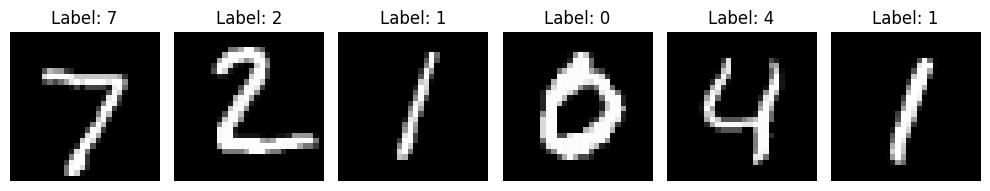

In [7]:
images, labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Define the CNN classifier


In [8]:
# Simple CNN classifier for MNIST
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Initialize model, loss, and optimizer


In [9]:
model = MNISTClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["lr"])

print(model)


MNISTClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Training loop for the classifier


In [10]:
# Train the classifier
for epoch in range(config["epochs"]):
    model.train()
    train_loss_list = []
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_list.append(loss.item())

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = np.mean(train_loss_list)
    train_acc = correct / total

    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_acc": train_acc
    }, step=epoch + 1)


Epoch [1/100] | Train Loss: 0.2391 | Train Acc: 0.9265
Epoch [2/100] | Train Loss: 0.0570 | Train Acc: 0.9828
Epoch [3/100] | Train Loss: 0.0399 | Train Acc: 0.9874
Epoch [4/100] | Train Loss: 0.0302 | Train Acc: 0.9901
Epoch [5/100] | Train Loss: 0.0230 | Train Acc: 0.9924
Epoch [6/100] | Train Loss: 0.0185 | Train Acc: 0.9938
Epoch [7/100] | Train Loss: 0.0153 | Train Acc: 0.9955
Epoch [8/100] | Train Loss: 0.0119 | Train Acc: 0.9961
Epoch [9/100] | Train Loss: 0.0119 | Train Acc: 0.9960
Epoch [10/100] | Train Loss: 0.0089 | Train Acc: 0.9971
Epoch [11/100] | Train Loss: 0.0082 | Train Acc: 0.9975
Epoch [12/100] | Train Loss: 0.0080 | Train Acc: 0.9973
Epoch [13/100] | Train Loss: 0.0051 | Train Acc: 0.9983
Epoch [14/100] | Train Loss: 0.0059 | Train Acc: 0.9980
Epoch [15/100] | Train Loss: 0.0063 | Train Acc: 0.9978
Epoch [16/100] | Train Loss: 0.0043 | Train Acc: 0.9985
Epoch [17/100] | Train Loss: 0.0036 | Train Acc: 0.9987
Epoch [18/100] | Train Loss: 0.0041 | Train Acc: 0.9985
E

## Evaluate the classifier on the test set


In [11]:
# Evaluate on test set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

wandb.log({"test_acc": test_acc})


Test Accuracy: 0.9932


## Find correctly classified digit 4 samples


In [12]:
# Collect correctly classified test images of digit 4
model.eval()

selected_images = []
selected_labels = []

source_digit = config["target_source_digit"]

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        mask = (labels == source_digit) & (preds == source_digit)

        matched_images = images[mask]
        matched_labels = labels[mask]

        for i in range(matched_images.size(0)):
            selected_images.append(matched_images[i:i+1].clone())
            selected_labels.append(matched_labels[i:i+1].clone())

        if len(selected_images) >= 10:
            break

selected_images = selected_images[:10]
selected_labels = selected_labels[:10]

print(f"Collected {len(selected_images)} correctly classified digit-{source_digit} images.")


Collected 10 correctly classified digit-4 images.


## Visualize the selected digit 4 images


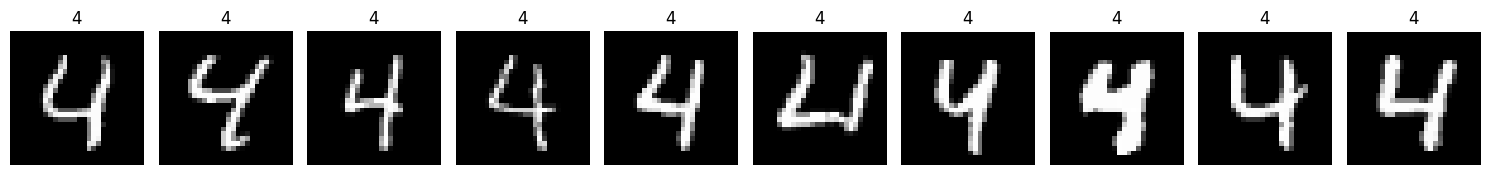

In [13]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(selected_images[i].squeeze().cpu().numpy(), cmap="gray")
    axes[i].set_title("4")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Create targeted adversarial images: 4 -> 9


In [14]:
# Create targeted adversarial examples using iterative gradient updates
def targeted_attack(model, image, target_label, epsilon=0.25, steps=50, alpha=0.01):
    model.eval()

    original = image.clone().detach().to(device)
    adv = image.clone().detach().to(device)
    adv.requires_grad = True

    target = torch.tensor([target_label], device=device)

    for _ in range(steps):
        logits = model(adv)
        loss = F.cross_entropy(logits, target)

        model.zero_grad()
        if adv.grad is not None:
            adv.grad.zero_()

        loss.backward()

        # Targeted attack: move input to minimize target loss
        adv = adv - alpha * adv.grad.sign()

        # Keep perturbation bounded around the original image
        perturbation = torch.clamp(adv - original, min=-epsilon, max=epsilon)
        adv = torch.clamp(original + perturbation, 0.0, 1.0).detach()
        adv.requires_grad = True

    return adv.detach()


## Generate adversarial images for 4 -> 9


In [15]:
# Generate adversarial examples
target_digit = config["target_attack_digit"]

adv_images = []
adv_preds = []

model.eval()

for img in selected_images:
    adv = targeted_attack(
        model=model,
        image=img,
        target_label=target_digit,
        epsilon=config["epsilon"],
        steps=50,
        alpha=0.01
    )

    with torch.no_grad():
        pred = model(adv).argmax(dim=1).item()

    adv_images.append(adv)
    adv_preds.append(pred)

print("Predicted labels for adversarial images:", adv_preds)


Predicted labels for adversarial images: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]


## Show original vs adversarial images


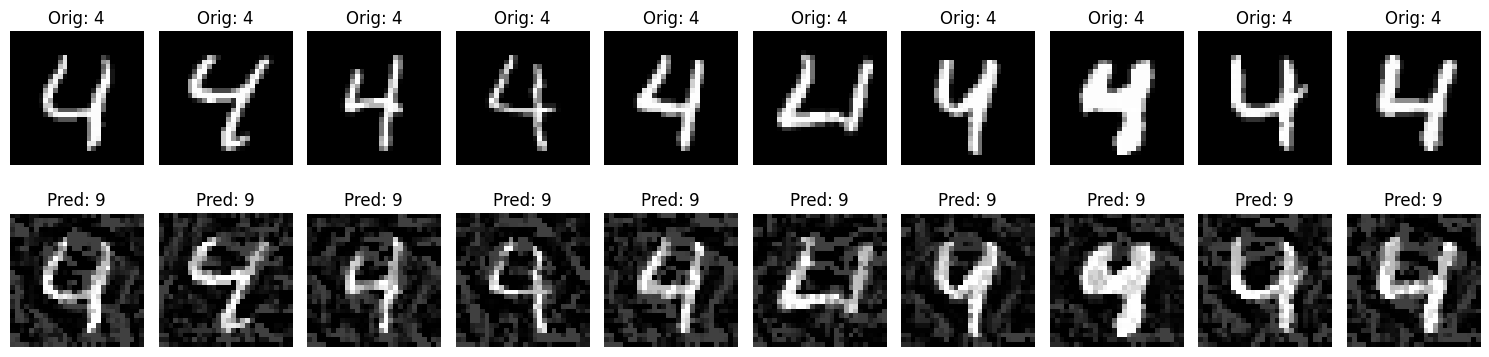

In [16]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    # Original
    axes[0, i].imshow(selected_images[i].squeeze().cpu().numpy(), cmap="gray")
    axes[0, i].set_title("Orig: 4")
    axes[0, i].axis("off")

    # Adversarial
    axes[1, i].imshow(adv_images[i].squeeze().cpu().numpy(), cmap="gray")
    axes[1, i].set_title(f"Pred: {adv_preds[i]}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## Optimize a random noise image to be classified as 9


In [17]:
# Optimize a random noise image so that the classifier predicts the target digit
def optimize_noise_to_target(model, target_label, steps=300, lr=0.05):
    model.eval()

    noise = torch.rand(1, 1, 28, 28, device=device, requires_grad=True)
    optimizer_noise = optim.Adam([noise], lr=lr)
    target = torch.tensor([target_label], device=device)

    for _ in range(steps):
        logits = model(noise)
        loss = F.cross_entropy(logits, target)

        optimizer_noise.zero_grad()
        loss.backward()
        optimizer_noise.step()

        with torch.no_grad():
            noise.clamp_(0.0, 1.0)

    return noise.detach()


## Generate and classify the optimized random noise image


In [18]:
target_digit = config["target_attack_digit"]

optimized_noise = optimize_noise_to_target(
    model=model,
    target_label=target_digit,
    steps=config["random_noise_steps"],
    lr=config["random_noise_lr"]
)

with torch.no_grad():
    noise_logits = model(optimized_noise)
    noise_pred = noise_logits.argmax(dim=1).item()
    noise_probs = torch.softmax(noise_logits, dim=1)

print("Predicted label for optimized noise image:", noise_pred)
print("Confidence for target digit 9:", noise_probs[0, target_digit].item())


Predicted label for optimized noise image: 9
Confidence for target digit 9: 1.0


## Visualize the optimized random noise image


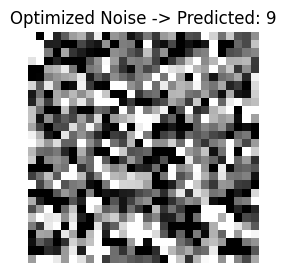

In [19]:
plt.figure(figsize=(3, 3))
plt.imshow(optimized_noise.squeeze().cpu().numpy(), cmap="gray")
plt.title(f"Optimized Noise -> Predicted: {noise_pred}")
plt.axis("off")
plt.show()


## Compare adversarial image and optimized random noise


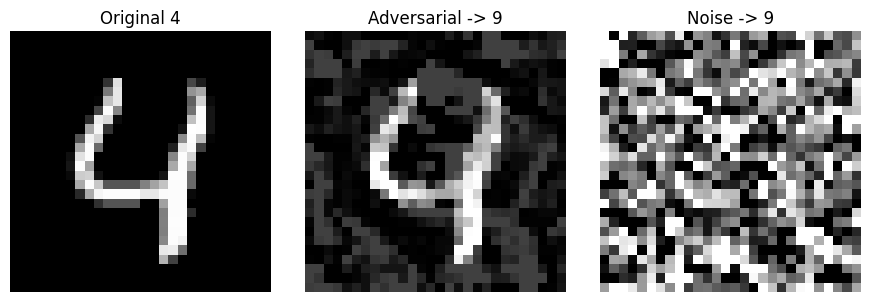

In [20]:
# Compare one original 4, one adversarial 4->9 image, and the optimized random noise image
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(selected_images[0].squeeze().cpu().numpy(), cmap="gray")
axes[0].set_title("Original 4")
axes[0].axis("off")

axes[1].imshow(adv_images[0].squeeze().cpu().numpy(), cmap="gray")
axes[1].set_title(f"Adversarial -> {adv_preds[0]}")
axes[1].axis("off")

axes[2].imshow(optimized_noise.squeeze().cpu().numpy(), cmap="gray")
axes[2].set_title(f"Noise -> {noise_pred}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Save result images locally


In [21]:
# Save comparison figure
comparison_path = OUT_DIR / "task4_comparison.png"

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(selected_images[0].squeeze().cpu().numpy(), cmap="gray")
axes[0].set_title("Original 4")
axes[0].axis("off")

axes[1].imshow(adv_images[0].squeeze().cpu().numpy(), cmap="gray")
axes[1].set_title(f"Adversarial -> {adv_preds[0]}")
axes[1].axis("off")

axes[2].imshow(optimized_noise.squeeze().cpu().numpy(), cmap="gray")
axes[2].set_title(f"Noise -> {noise_pred}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(comparison_path, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison figure to: {comparison_path}")


Saved comparison figure to: /root/D7047E/Lab2/out/task4_comparison.png


## Save trained classifier


In [22]:
checkpoint_name = build_model_name(config, task_name="task4_classifier")
checkpoint_path = MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 4",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")


Checkpoint saved to: /root/D7047E/Lab2/Models/task4_classifier_ep100_bs128_lr0.001_seed1_20260419_151633.pt


## Log final images to W&B


In [23]:
wandb.log({
    "comparison_figure": wandb.Image(str(comparison_path)),
    "optimized_noise_prediction": noise_pred
})


## Finish the W&B run


In [24]:
wandb.finish()


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
optimized_noise_prediction,▁
test_acc,▁
train_acc,▁▄▆▆▇▇▇▇█▇████████████████████████████▇█
train_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
optimized_noise_prediction,9
test_acc,0.9932
train_acc,1
train_loss,1e-05
